In [4]:
# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.utils.class_weight import compute_sample_weight

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv('../data/Student Social Media And Mental Health Impact.csv')

In [6]:
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (5000, 13)


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [7]:
# =========================================================
# 2. BASIC DATA CHECK
# =========================================================

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicated Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (5000, 13)

Column Names:
['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night', 'Stress_Level', 'Mental_Health_Score']

Missing Values:
Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

Duplicated Rows: 2

Data Types:
Age                          int64
Gender                         str
Country                        str
Academic_Level                 str
Most_Used_Platform             str
Purpose_Of_Use                 str
Avg_Daily_Usage_Hours      float64
Daily_Unlocks                int64
Stud

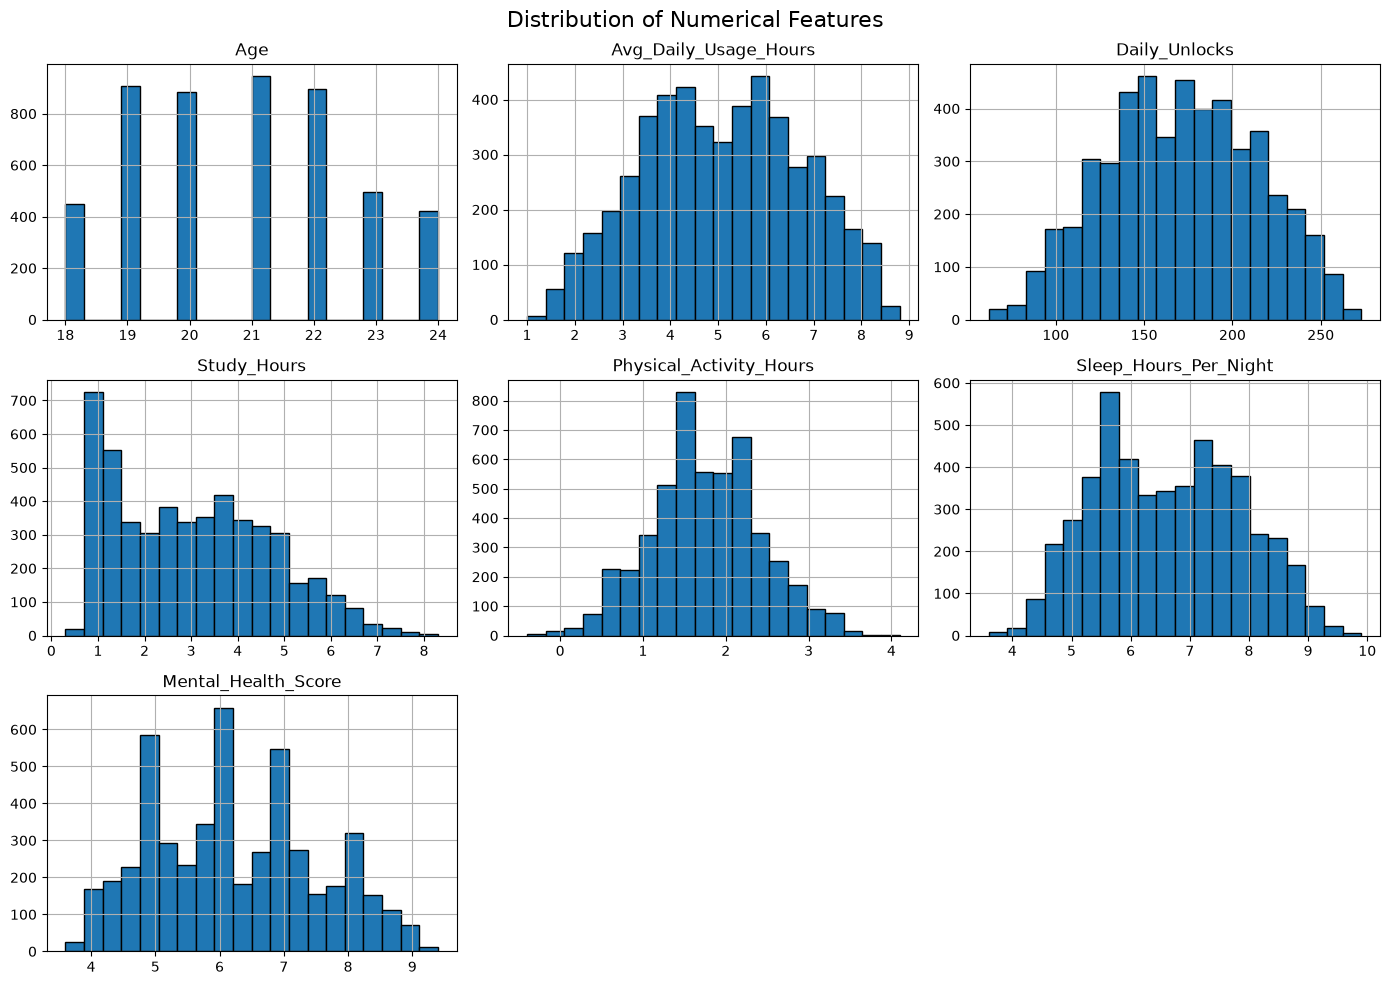

In [8]:
# =========================================================
# 3. EDA - HISTOGRAMS
# =========================================================

numeric_cols = [
    "Age",
    "Avg_Daily_Usage_Hours",
    "Daily_Unlocks",
    "Study_Hours",
    "Physical_Activity_Hours",
    "Sleep_Hours_Per_Night",
    "Mental_Health_Score"
]

df[numeric_cols].hist(
    figsize=(14, 10),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
# =========================================================
# 4. OUTLIER CHECK USING Z-SCORE
# =========================================================

outlier_cols = [
    "Age",
    "Avg_Daily_Usage_Hours",
    "Sleep_Hours_Per_Night"
]

z_scores = np.abs(
    stats.zscore(
        df[outlier_cols],
        nan_policy="omit"
    )
)

outlier_mask = (z_scores > 3).any(axis=1)

print("Original rows:", len(df))
print("Potential outlier rows:", outlier_mask.sum())
print("Percentage:", round(outlier_mask.mean() * 100, 2), "%")

Original rows: 5000
Potential outlier rows: 0
Percentage: 0.0 %


In [10]:
# =========================================================
# 5. CREATE MENTAL HEALTH CATEGORY
# =========================================================

bins = [0, 4, 7, 10]
labels = ["Poor", "Fair", "Good"]

df["Mental_Health_Category"] = pd.cut(
    df["Mental_Health_Score"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Remove rows if score does not fall into our defined range
df = df.dropna(subset=["Mental_Health_Category"])

print(df["Mental_Health_Category"].value_counts())

Mental_Health_Category
Fair    3610
Good    1273
Poor     117
Name: count, dtype: int64


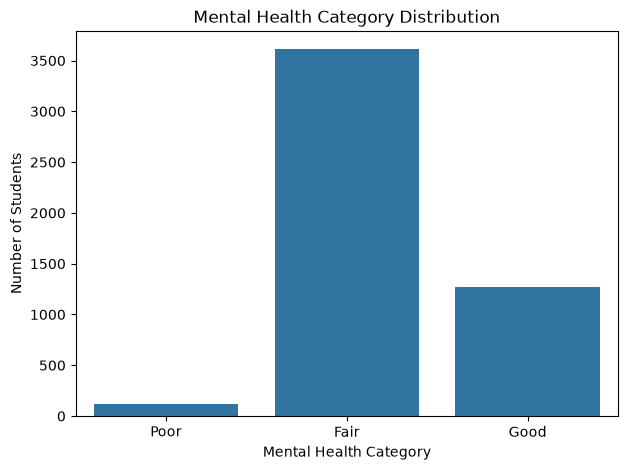

Mental_Health_Category
Fair    72.20
Good    25.46
Poor     2.34
Name: proportion, dtype: float64


In [11]:
# =========================================================
# 6. CLASS DISTRIBUTION
# =========================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Mental_Health_Category"
)

plt.title("Mental Health Category Distribution")
plt.xlabel("Mental Health Category")
plt.ylabel("Number of Students")
plt.show()

print(
    df["Mental_Health_Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

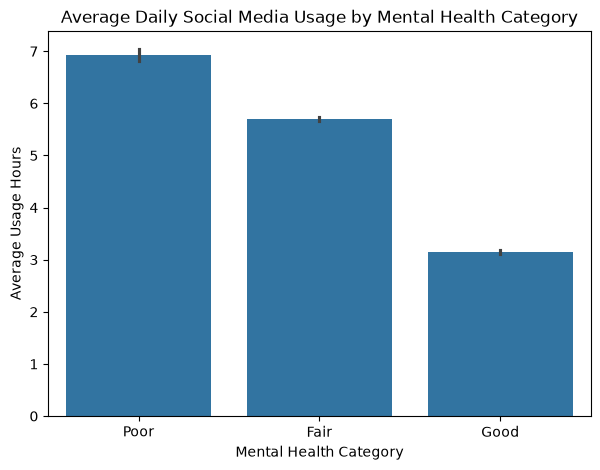

In [12]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Mental_Health_Category",
    y="Avg_Daily_Usage_Hours"
)

plt.title("Average Daily Social Media Usage by Mental Health Category")
plt.xlabel("Mental Health Category")
plt.ylabel("Average Usage Hours")
plt.show()

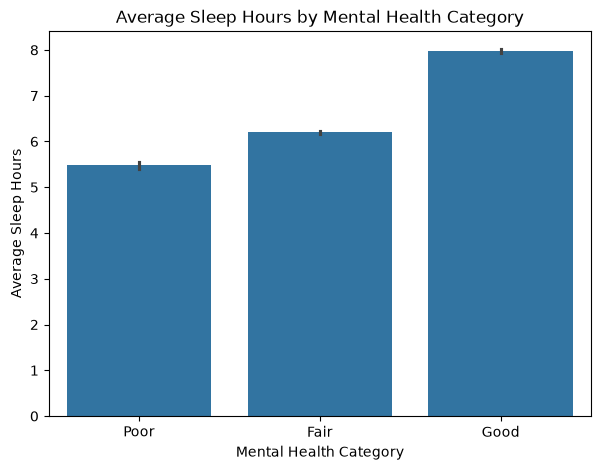

In [13]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Mental_Health_Category",
    y="Sleep_Hours_Per_Night"
)

plt.title("Average Sleep Hours by Mental Health Category")
plt.xlabel("Mental Health Category")
plt.ylabel("Average Sleep Hours")
plt.show()

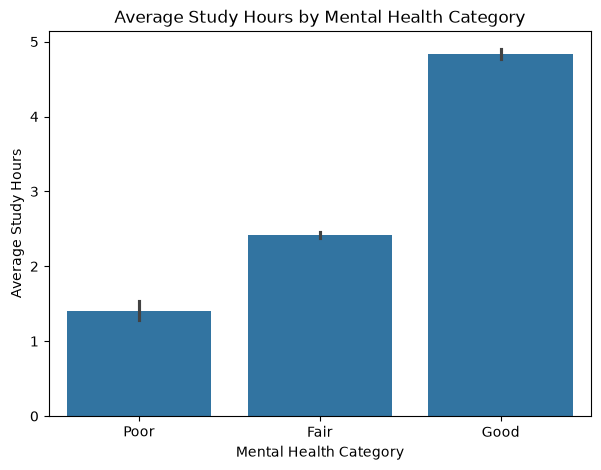

In [14]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="Mental_Health_Category",
    y="Study_Hours"
)

plt.title("Average Study Hours by Mental Health Category")
plt.xlabel("Mental Health Category")
plt.ylabel("Average Study Hours")
plt.show()

Stress_Level             High    Low  Medium  Very High
Mental_Health_Category                                 
Poor                     6.84   0.00    0.00      93.16
Fair                    37.17   2.58   18.42      41.83
Good                     7.07  43.28   49.49       0.16


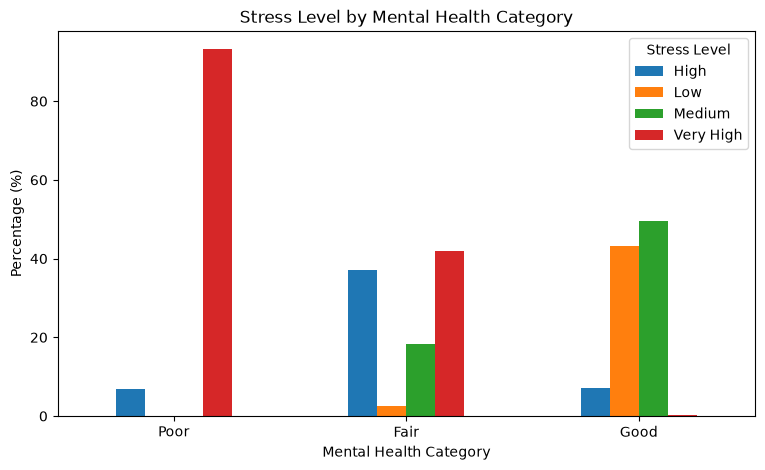

In [15]:
# =========================================================
# STRESS LEVEL VS MENTAL HEALTH
# =========================================================

stress_table = pd.crosstab(
    df["Mental_Health_Category"],
    df["Stress_Level"],
    normalize="index"
) * 100

print(stress_table.round(2))

stress_table.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Stress Level by Mental Health Category")
plt.xlabel("Mental Health Category")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Stress Level")
plt.show()

In [16]:
# =========================================================
# 7. PREPARE FEATURES AND TARGET
# =========================================================

# Target
y_raw = df["Mental_Health_Category"]

# Encode target
le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Target mapping:")
for i, label in enumerate(le.classes_):
    print(i, "=", label)

Target mapping:
0 = Fair
1 = Good
2 = Poor


In [17]:
# =========================================================
# CREATE FEATURE DATA
# =========================================================

X_raw = df.drop(
    columns=[
        "Mental_Health_Score",
        "Mental_Health_Category",
        "Stress_Level"
    ],
    errors="ignore"
)

# One-hot encode categorical variables
X = pd.get_dummies(
    X_raw,
    drop_first=True
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 133)
y shape: (5000,)


In [18]:
# =========================================================
# TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts())

Training samples: 4000
Testing samples: 1000

Training class distribution:
0    2888
1    1018
2      94
Name: count, dtype: int64

Testing class distribution:
0    722
1    255
2     23
Name: count, dtype: int64


In [19]:
# =========================================================
# 8. LOGISTIC REGRESSION
# =========================================================

pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_lr = {
    "lr__C": [0.01, 0.1, 1, 10],
    "lr__solver": ["lbfgs", "newton-cg"]
}

lr_grid = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

print("Training Logistic Regression...")

lr_grid.fit(X_train, y_train)

best_lr = lr_grid.best_estimator_

y_pred_lr = best_lr.predict(X_test)

print("\nBest Parameters:")
print(lr_grid.best_params_)

print("\nLogistic Regression Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=le.classes_
    )
)

Training Logistic Regression...

Best Parameters:
{'lr__C': 1, 'lr__solver': 'lbfgs'}

Logistic Regression Report:
              precision    recall  f1-score   support

        Fair       0.96      0.66      0.78       722
        Good       0.74      0.93      0.82       255
        Poor       0.11      0.87      0.20        23

    accuracy                           0.73      1000
   macro avg       0.60      0.82      0.60      1000
weighted avg       0.88      0.73      0.78      1000



In [20]:
# =========================================================
# 9A. RANDOM FOREST - GINI
# =========================================================

rf_gini = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        criterion="gini"
    ),
    param_grid={
        "n_estimators": [100, 200],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5]
    },
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

print("Training Random Forest - Gini...")

rf_gini.fit(X_train, y_train)

best_rf_gini = rf_gini.best_estimator_

y_pred_rf_gini = best_rf_gini.predict(X_test)

print("\nBest Parameters:")
print(rf_gini.best_params_)

print("\nRandom Forest - Gini:")
print(
    classification_report(
        y_test,
        y_pred_rf_gini,
        target_names=le.classes_
    )
)

Training Random Forest - Gini...



Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Random Forest - Gini:
              precision    recall  f1-score   support

        Fair       0.95      0.91      0.93       722
        Good       0.81      0.91      0.86       255
        Poor       0.52      0.52      0.52        23

    accuracy                           0.90      1000
   macro avg       0.76      0.78      0.77      1000
weighted avg       0.90      0.90      0.90      1000



In [21]:
# =========================================================
# 10. XGBOOST
# =========================================================

xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",
    objective="multi:softprob",
    num_class=len(le.classes_)
)

param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6],
    "learning_rate": [0.01, 0.1]
}

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

# Balanced sample weights
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print("Training XGBoost...")

xgb_grid.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

best_xgb = xgb_grid.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

print("\nBest Parameters:")
print(xgb_grid.best_params_)

print("\nXGBoost Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=le.classes_
    )
)

Training XGBoost...

Best Parameters:
{'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 200}

XGBoost Report:
              precision    recall  f1-score   support

        Fair       0.95      0.78      0.86       722
        Good       0.76      0.91      0.83       255
        Poor       0.17      0.78      0.28        23

    accuracy                           0.81      1000
   macro avg       0.63      0.82      0.65      1000
weighted avg       0.89      0.81      0.84      1000



In [22]:
# =========================================================
# XGBOOST FEATURE IMPORTANCE USING GAIN
# =========================================================

gain_scores = best_xgb.get_booster().get_score(
    importance_type="gain"
)

gain_df = pd.DataFrame(
    gain_scores.items(),
    columns=["Feature", "Gain"]
).sort_values(
    by="Gain",
    ascending=False
)

print(gain_df.head(15))

                         Feature       Gain
1          Avg_Daily_Usage_Hours  66.396622
11        Country_Czech Republic  23.518257
5          Sleep_Hours_Per_Night  16.308952
36   Most_Used_Platform_WhatsApp  16.144352
38  Purpose_Of_Use_Entertainment  13.096866
30  Academic_Level_Undergraduate  12.877696
37    Most_Used_Platform_YouTube   9.840700
40           Purpose_Of_Use_News   9.798031
17                 Country_Japan   9.770474
32   Most_Used_Platform_LinkedIn   9.104474
29                   Country_USA   8.983088
24                Country_Russia   8.564669
33   Most_Used_Platform_Snapchat   7.115839
27                Country_Turkey   7.058626
28                   Country_UAE   6.784581


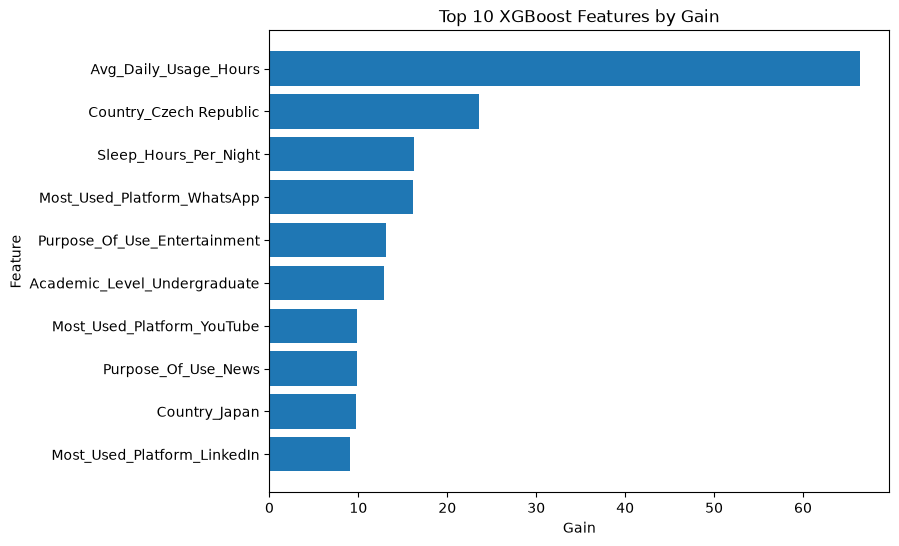

In [23]:
plt.figure(figsize=(8, 6))

top_gain = gain_df.head(10)

plt.barh(
    top_gain["Feature"][::-1],
    top_gain["Gain"][::-1]
)

plt.title("Top 10 XGBoost Features by Gain")
plt.xlabel("Gain")
plt.ylabel("Feature")

plt.show()

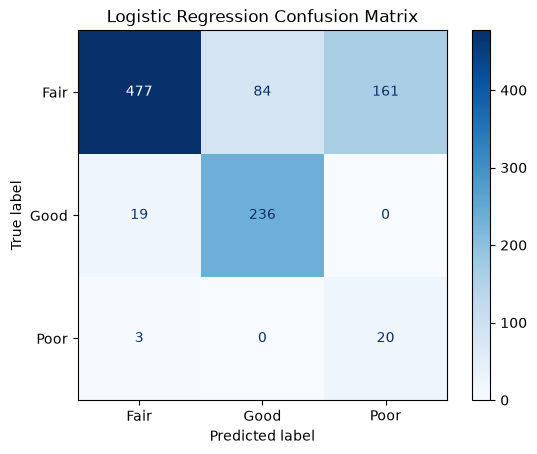

In [24]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=le.classes_,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

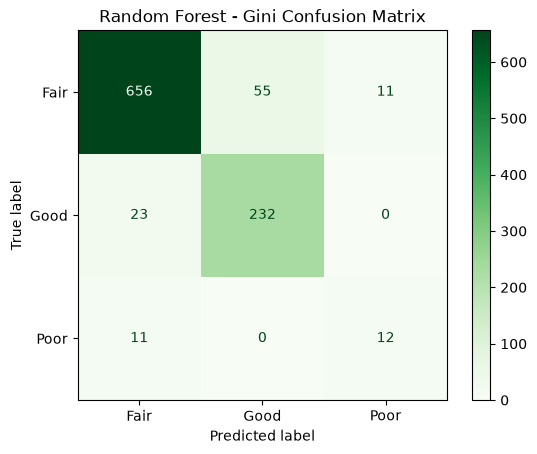

In [25]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_gini,
    display_labels=le.classes_,
    cmap="Greens"
)

plt.title("Random Forest - Gini Confusion Matrix")
plt.show()

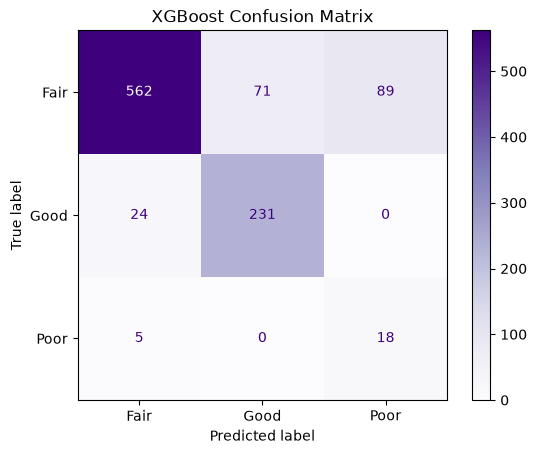

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=le.classes_,
    cmap="Purples"
)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [27]:
# =========================================================
# 11. MODEL COMPARISON
# =========================================================

models = {
    "Logistic Regression": y_pred_lr,
    "Random Forest - Gini": y_pred_rf_gini,
    "XGBoost": y_pred_xgb
}

results = []

for name, predictions in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        by="F1 Score",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest - Gini,0.900,0.760275,0.780043,0.769002
2,XGBoost,0.811,0.628019,0.822295,0.654140
0,Logistic Regression,0.733,0.601303,0.818573,0.599425


In [28]:
# =========================================================
# CHECK PERFORMANCE FOR EACH CLASS
# =========================================================

print("Classes:")
print(le.classes_)

print("\nRandom Forest Gini:")
print(
    classification_report(
        y_test,
        y_pred_rf_gini,
        target_names=le.classes_,
        zero_division=0
    )
)

Classes:
['Fair' 'Good' 'Poor']

Random Forest Gini:
              precision    recall  f1-score   support

        Fair       0.95      0.91      0.93       722
        Good       0.81      0.91      0.86       255
        Poor       0.52      0.52      0.52        23

    accuracy                           0.90      1000
   macro avg       0.76      0.78      0.77      1000
weighted avg       0.90      0.90      0.90      1000



In [29]:
# =========================================================
# FIND REAL TEST EXAMPLES
# =========================================================

test_results = X_test.copy()

test_results["Actual"] = le.inverse_transform(y_test)
test_results["Predicted"] = le.inverse_transform(y_pred_rf_gini)

# Show examples from each class
for category in le.classes_:

    print("\n==============================")
    print(category)
    print("==============================")

    examples = test_results[
        test_results["Actual"] == category
    ].head(3)

    display(
        examples[
            ["Age",
             "Avg_Daily_Usage_Hours",
             "Daily_Unlocks",
             "Study_Hours",
             "Sleep_Hours_Per_Night",
             "Physical_Activity_Hours",
             "Actual",
             "Predicted"]
        ]
    )


Fair


,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Sleep_Hours_Per_Night,Physical_Activity_Hours,Actual,Predicted
1350,20,4.9,154,4.1,7.0,1.6,Fair,Fair
4668,20,5.3,192,3.6,5.4,1.7,Fair,Fair
2031,19,6.7,213,1.1,5.4,1.6,Fair,Fair



Good


,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Sleep_Hours_Per_Night,Physical_Activity_Hours,Actual,Predicted
4170,19,2.2,93,5.6,7.4,3.2,Good,Good
2780,20,3.7,151,2.5,8.4,2.6,Good,Good
2126,21,3.9,150,4.7,6.4,1.9,Good,Fair



Poor


,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Sleep_Hours_Per_Night,Physical_Activity_Hours,Actual,Predicted
1284,19,6.7,198,1.0,5.4,1.4,Poor,Poor
1316,19,7.1,230,2.1,5.0,1.1,Poor,Poor
3928,18,6.7,195,0.9,4.9,1.8,Poor,Fair


In [30]:
%pip install gradio -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
# This line is no longer needed as model selection is handled within the predict_mental_health function.

In [32]:
import gradio as gr

def predict_mental_health(
    model_choice,
    age,
    usage_hours,
    unlocks,
    study_hours,
    sleep_hours,
    physical_hours,
    gender,
    country,
    academic_level,
    platform,
    purpose
):

    # Select the model based on user choice
    if model_choice == "Logistic Regression":
        selected_model = best_lr
    elif model_choice == "Random Forest - Gini":
        selected_model = best_rf_gini
    elif model_choice == "XGBoost":
        selected_model = best_xgb
    else:
        return "Invalid model choice"

    # Create empty row with EXACT training columns
    input_df = pd.DataFrame(
        0,
        index=[0],
        columns=X.columns
    )

    # Numerical features
    input_df["Age"] = age
    input_df["Avg_Daily_Usage_Hours"] = usage_hours
    input_df["Daily_Unlocks"] = unlocks
    input_df["Study_Hours"] = study_hours
    input_df["Sleep_Hours_Per_Night"] = sleep_hours
    input_df["Physical_Activity_Hours"] = physical_hours

    # Gender
    if gender == "Male":
        if "Gender_Male" in input_df.columns:
            input_df["Gender_Male"] = 1

    # Country
    country_col = f"Country_{country}"

    if country_col in input_df.columns:
        input_df[country_col] = 1

    # Academic level
    academic_col = f"Academic_Level_{academic_level}"

    if academic_col in input_df.columns:
        input_df[academic_col] = 1

    # Platform
    platform_col = f"Most_Used_Platform_{platform}"

    if platform_col in input_df.columns:
        input_df[platform_col] = 1

    # Purpose
    purpose_col = f"Purpose_Of_Use_{purpose}"

    if purpose_col in input_df.columns:
        input_df[purpose_col] = 1

    # Prediction
    prediction = selected_model.predict(input_df)[0]

    result = le.inverse_transform([prediction])[0]

    # Probability
    probabilities = selected_model.predict_proba(input_df)[0]

    probability_text = ""

    for class_name, probability in zip(
        le.classes_,
        probabilities
    ):
        probability_text += (
            f"{class_name}: {probability:.1%}\n"
        )

    return (
        f"Predicted Mental Health Category: {result}\n\n"
        f"Prediction Probabilities:\n"
        f"{probability_text}"
    )

In [33]:
demo = gr.Interface(

    fn=predict_mental_health,

    inputs=[
        gr.Dropdown(
            [
                "Logistic Regression",
                "Random Forest - Gini",
                "XGBoost"
            ],
            value="Random Forest - Gini",
            label="Select Model"
        ),
        gr.Slider(
            18, 24,
            value=20,
            step=1,
            label="Age"
        ),

        gr.Slider(
            1, 9,
            value=5,
            step=0.1,
            label="Daily Social Media Usage (Hours)"
        ),

        gr.Slider(
            0, 300,
            value=150,
            step=5,
            label="Daily Phone Unlocks"
        ),

        gr.Slider(
            0, 12,
            value=3,
            step=0.5,
            label="Study Hours"
        ),

        gr.Slider(
            4, 10,
            value=7,
            step=0.5,
            label="Sleep Hours"
        ),

        gr.Slider(
            0, 5,
            value=1.5,
            step=0.5,
            label="Physical Activity (Hours)"
        ),

        gr.Dropdown(
            ["Female", "Male"],
            value="Female",
            label="Gender"
        ),

        gr.Dropdown(
            sorted([
                c.replace("Country_", "")
                for c in X.columns
                if c.startswith("Country_")
            ]),
            value="Other",
            label="Country"
        ),

        gr.Dropdown(
            ["High School", "Undergraduate"],
            value="Undergraduate",
            label="Academic Level"
        ),

        gr.Dropdown(
            [
                "Instagram",
                "KakaoTalk",
                "LINE",
                "LinkedIn",
                "Snapchat",
                "TikTok",
                "Twitter",
                "VKontakte",
                "WeChat",
                "WhatsApp",
                "YouTube"
            ],
            value="Instagram",
            label="Most Used Platform"
        ),

        gr.Dropdown(
            [
                "Entertainment",
                "Networking",
                "News"
            ],
            value="Entertainment",
            label="Purpose of Use"
        )
    ],

    outputs=gr.Textbox(
        label="Prediction Result"
    ),

    title="🧠 Student Mental Health Prediction System",

    description=(
        "Predict whether a student's mental health category "
        "is Poor, Fair, or Good using Machine Learning."
    )
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
